# Modelo de clasificación en Riesgo de Crédito

## El Problema de Negocio:
Imagina que trabajas en el departamento de Riesgos de un banco. Cada día llegan miles de solicitudes de tarjetas de crédito. Aprobar a un cliente que luego no paga (moroso) le cuesta mucho dinero al banco. Rechazar a un buen cliente significa perder ingresos y dárselos a la competencia. 

## Objetivo:
Construir un modelo de Machine Learning capaz de clasificar si un cliente es de "Alto Riesgo" (```Label``` = 1) o "Bajo Riesgo" (``Label`` = 0) basándonos en sus datos demográficos y financieros antes de concederle la tarjeta. 

## Marco de Coste de Negocio

Vamos a asignar un coste aproximado (ilustrativo, no oficial del banco) a cada tipo de error, para poder traducir cualquier métrica a dólares en cualquier punto del análisis:

- **Falso Negativo (FN):** aprobamos una tarjeta a alguien que termina siendo moroso. Coste: el capital que el banco pierde de golpe. Lo fijamos en **8.000$** de media por caso.

- **Falso Positivo (FP):** rechazamos a un cliente que en realidad era bueno pagador. Coste: el margen de intereses que dejamos de ganar y que probablemente se lleva la competencia. Lo fijamos en **400$** de media por caso.

La proporción (20:1) no es casualidad. En riesgo de crédito, un impago suele doler bastante más que un rechazo de más. Este marco es exactamente lo que vamos a usar más adelante para elegir el umbral de decisión y para la traducción final a euros de cada modelo.

## El Contexto de Negocio

Imagina que trabajas en el departamento de Admisión de Riesgos de un banco. Cada día, miles de clientes solicitan una nueva tarjeta de crédito a través de la app. El problema es crítico: cada vez que el banco le da una tarjeta a un cliente que luego no paga (moroso), se pierden miles de euros de golpe. Pero si el banco se asusta y rechaza a los buenos clientes, le está regalando el negocio y los intereses a la competencia.

La dirección te ha entregado un histórico de clientes reales. Su objetivo es claro: necesitan un modelo de *Credit Scoring* automático que sea capaz de predecir si un solicitante es de Alto Riesgo o Bajo Riesgo en tiempo real, antes de concederle el dinero.

In [717]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

Definimos costes de cada decisión

In [718]:
COSTE_FALSO_NEGATIVO = 8000   # $ perdidos por aprobar a un moroso
COSTE_FALSO_POSITIVO = 400    # $ de oportunidad perdidos por rechazar a un buen cliente

print(f"Ratio de coste FN/FP: {COSTE_FALSO_NEGATIVO / COSTE_FALSO_POSITIVO:.0f}:1")

Ratio de coste FN/FP: 20:1


In [719]:
# carga de los CSV y hacemos merge por la columna en comun Ind_ID
df_features = pd.read_csv("../data/raw/Credit_card.csv")
df_labels = pd.read_csv("../data/raw/Credit_card_label.csv")

df = pd.merge(df_features, df_labels, on="Ind_ID", how="inner")

verificación del merge y duplicados

In [720]:
ids_solo_features = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"]) 
ids_solo_labels = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"])

# validación de duplicados
duplicados_features = df_features['Ind_ID'].duplicated().sum()
duplicados_labels = df_labels['Ind_ID'].duplicated().sum()

# Filas perdidas
filas_perdidas = len(df_features) - len(df)

print(f"Clientes con datos pero sin etiqueta de riesgo: {len(ids_solo_features)}")
print(f"Clientes con etiquetas pero sin datos: {len(ids_solo_labels)}")

print(f"IDs duplicados en features: {duplicados_features}")
print(f"IDs duplicados en labels: {duplicados_labels}")

print(f"\nFilas descartadas por el inner join: {filas_perdidas} ({100*filas_perdidas/len(df_features):.2f}% del total)")

Clientes con datos pero sin etiqueta de riesgo: 0
Clientes con etiquetas pero sin datos: 0
IDs duplicados en features: 0
IDs duplicados en labels: 0

Filas descartadas por el inner join: 0 (0.00% del total)


Observamos que la distribución de pagadores no esta equilibrada, por un lado vemos que la basta mayoria 88% son buenos pagadores;sin embargo, tenemos una minoria del 11% que no son buenos pagadores. 

label
0    0.886951
1    0.113049
Name: proportion, dtype: float64


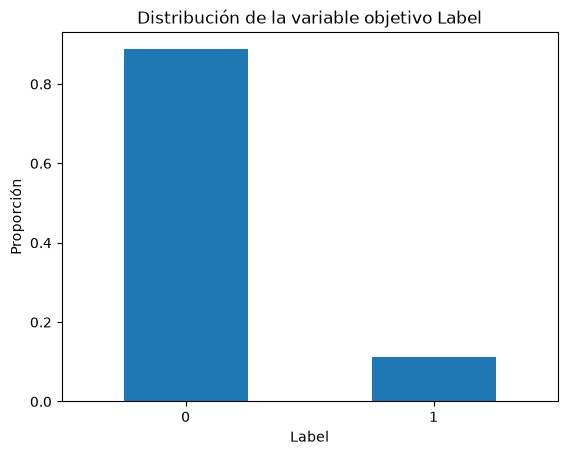

In [721]:
print(df["label"].value_counts(normalize=True))

df["label"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribución de la variable objetivo Label")
plt.xlabel("Label")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

En el análisis descriptivo observamos variables de propiedad `Car_owner`, `Propert_owner` `EMAIL_ID`,`Work_phone`,`Phone`,`Mobile_phone` veremos si tiene relación con ser un buen pagador o no. 

In [722]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ind_ID,1548.0,5.078920e+06,41717.587742,5008827.0,5045069.75,5078841.5,5115673.00,5150412.0
CHILDREN,1548.0,4.127907e-01,0.776691,0.0,0.00,0.0,1.00,14.0
Annual_income,1525.0,1.913993e+05,113252.997656,33750.0,121500.00,166500.0,225000.00,1575000.0
Birthday_count,1526.0,-1.604034e+04,4229.503202,-24946.0,-19553.00,-15661.5,-12417.00,-7705.0
Employed_days,1548.0,5.936469e+04,137808.062701,-14887.0,-3174.50,-1565.0,-431.75,365243.0
Mobile_phone,1548.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
Work_Phone,1548.0,2.080103e-01,0.406015,0.0,0.00,0.0,0.00,1.0
Phone,1548.0,3.094315e-01,0.462409,0.0,0.00,0.0,1.00,1.0
EMAIL_ID,1548.0,9.237726e-02,0.289651,0.0,0.00,0.0,0.00,1.0
Family_Members,1548.0,2.161499e+00,0.947772,1.0,2.00,2.0,3.00,15.0


## Limpieza e Ingeniería de Datos

Verificamos el formato de nuestras variables, parece todo estar correcto. Y eliminamos `Ind_ID` ya que solo este es un identificador. 

In [723]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   str    
 2   Car_Owner        1548 non-null   str    
 3   Propert_Owner    1548 non-null   str    
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   str    
 7   EDUCATION        1548 non-null   str    
 8   Marital_status   1548 non-null   str    
 9   Housing_type     1548 non-null   str    
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   str    
 17  Family_Members   1548 non

In [724]:
df.drop("Ind_ID", axis=1, inplace=True)

verificaremos los nulos. Vemos que tenemos una variable con muchos nulos `Type_Occupation` - En este punto nace una pregunta imporante: ¿El cliente esta desempleado, por eso la la casilla es nula? 

In [725]:
df.isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

Creamos un indicador para verificar si los nulos en `Type_Occupation` influyen en si un buen pagador o no.

In [726]:
df['Occupation_era_nulo'] = df['Type_Occupation'].isnull().astype(int)

print("Tasa de impago según si Type_Occupation estaba informado o no:")
print(df.groupby('Occupation_era_nulo')['label'].agg(['mean', 'count']))

Tasa de impago según si Type_Occupation estaba informado o no:
                         mean  count
Occupation_era_nulo                 
0                    0.111321   1060
1                    0.116803    488


Vemos que no existe mucha diferencia entre los usuarios con ocupación laboral y sin ocupación laboral a la hora de hacer sus pagos respectivos. Por lo tanto, eliminamos la variable que hemos creado.

In [727]:
df.drop("Occupation_era_nulo", axis=1, inplace=True)

En el diccionario nos indica que `Employed_days` > 0 significa que el usuario es deseempleado, evaluaremos en conjunto con el  `Type_Occupation`. Por lo tanto, asumimos que: Si `Employed_days` > 0 y ademas `Type_Occupation` es nulo, etiquetamos como "Unemployed". Lo cual tendría mucho sentido.

In [728]:
df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)].head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22134.0,365243,1,0,0,0,NaN,2,1
26,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,1,0,1,0,NaN,2,1
27,F,N,Y,0,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,1,0,1,0,NaN,2,1
31,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21876.0,365243,1,0,1,1,NaN,2,1


In [729]:
df.loc[
    df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)].index,
    'Type_Occupation'
] = "Unemployed"

Vemos que existe muchos tipos de ocupación, lo ideal seria agruparlos de modo que tengamos pocas "categorias", lo cual haremos en la seccion de Ingenieria de Datos, por ahora solo nos enfocamos en tratamiento de valores nulos.

In [730]:
df.Type_Occupation.value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

Para la variable `GENDER` tenemos 7 valores nulos, imputaremos con el genero mas frecuente.

In [731]:
print(df['GENDER'].value_counts())
print("Género mas frecuente: ", df['GENDER'].mode())
df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

GENDER
F    973
M    568
Name: count, dtype: int64
Género mas frecuente:  0    F
Name: GENDER, dtype: str


Continuamos para la variable `Annual_income`, vemos que no existen ingreso de 0, y tenemos 23 nulos.Imputaremos usando Q1, ya que es muy poco probable que existan ingresos anuales de 0 en un contexto real y práctico. 

In [732]:
print(df.Annual_income.isnull().sum())
df.Annual_income.describe().T

23


count    1.525000e+03
mean     1.913993e+05
std      1.132530e+05
min      3.375000e+04
25%      1.215000e+05
50%      1.665000e+05
75%      2.250000e+05
max      1.575000e+06
Name: Annual_income, dtype: float64

In [733]:
Q1 = df['Annual_income'].quantile(.25)
df.loc[df['Annual_income'].isnull(), 'Annual_income'] = Q1

Continuamos con la variable `Birthday_count`, esta variable indica con signo negativo los dias de nacimiento de un cliente hasta la actualidad. Trataremos de imputar esta variable con `Employed_days`. Además con solo 22 valores faltantes (1.4%) y una correlación moderada (0.34), por lo que la mediana introduce un sesgo mínimo, considerando el valor `365243` como un valor otorgado por defecto a los desempleados

In [734]:
df[['Birthday_count', 'Employed_days']].describe()

,Birthday_count,Employed_days
count,1526.000000,1548.000000
mean,-16040.342071,59364.689922
std,4229.503202,137808.062701
min,-24946.000000,-14887.000000
25%,-19553.000000,-3174.500000
50%,-15661.500000,-1565.000000
75%,-12417.000000,-431.750000
max,-7705.000000,365243.000000


In [735]:
df_empleados = df[df["Employed_days"] != 365243].copy()

df_empleados[["Birthday_count", "Employed_days"]].corr()

,Birthday_count,Employed_days
Birthday_count,1.000000,0.336366
Employed_days,0.336366,1.000000


In [736]:
df['Birthday_count'] = df['Birthday_count'].fillna(df['Birthday_count'].median())

df['Birthday_count'].describe()

count     1548.000000
mean    -16034.958010
std       4199.561035
min     -24946.000000
25%     -19476.000000
50%     -15661.500000
75%     -12483.000000
max      -7705.000000
Name: Birthday_count, dtype: float64

In [737]:
df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    227
Family_Members       0
label                0
dtype: int64

## Análisis Exploratorio

Creamos una lista de las variables categoricas y númericas para realizar gráficos estadistos por tipo de variable. Ademas observamos que las variables binarias lo consideran como numéricas cuando deberia de ser binaria/categórica

In [738]:
# Seleccionar columnas numéricas del dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categoricas: ", cat_cols)

Numericas:  ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'label']
Categoricas:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


In [739]:
# Convertimos estas variables en binarias
cols = ['Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID']

df[cols] = df[cols].replace({1: 'Si', 0: 'No'})

#verificamos
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categoricas: ", cat_cols)

Numericas:  ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'label']
Categoricas:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation']


Comenzaremos con la detección de outliers usando bloxplots

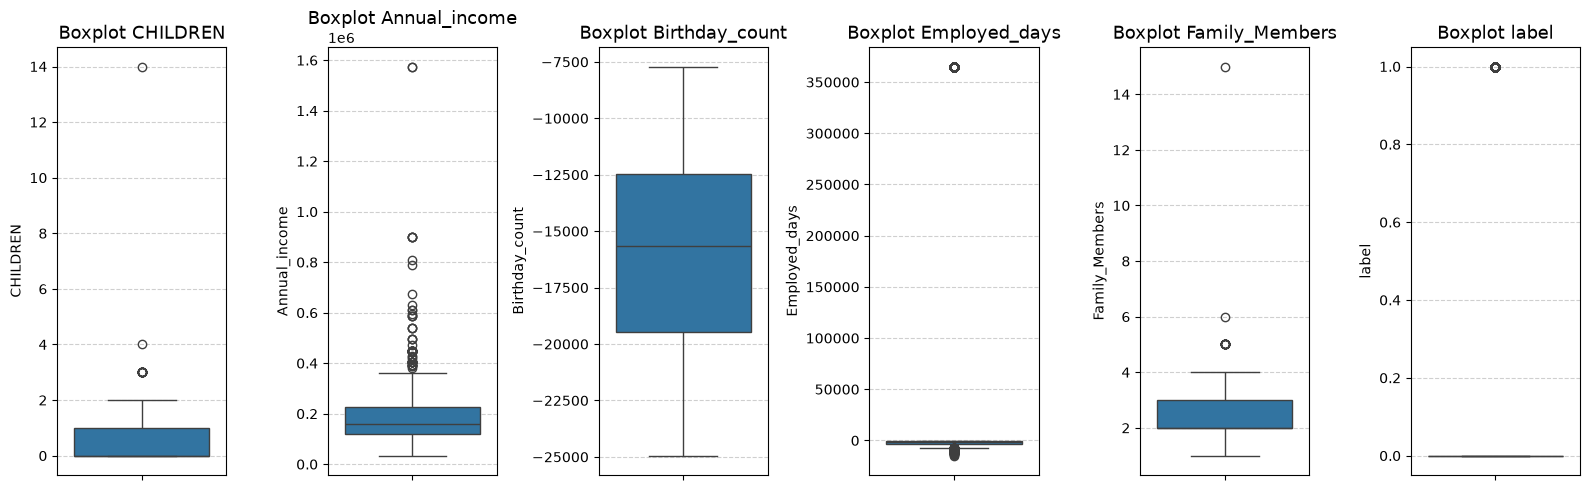

In [740]:
fig, axes = plt.subplots(ncols=len(num_cols), nrows=1, figsize=(16,5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data = df,
        y = col,
        ax = axes[i],
        legend = False,
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Se observa algunos outliers, por ejemplo en children y el numero de familiares, hoy por hoy no es muy normal tener 14 hijos. Por lo cual es necesario realizar una imputación y lo haremos por un valor razonable en este caso 5. 

Además, inputaremos los outilers de `Annual_income` con el quantile 99, el valor que deja por debajo al 99% de los datos.

In [741]:
df['CHILDREN'] = df['CHILDREN'].clip(upper=5)
df['Family_Members'] = df['Family_Members'].clip(upper = 5 + 2) # incluyendo madre y padre 


En el caso de la variable `Annual_income` trataremos los outliers por el limite superior IQR (Winsorizacion). Observamos que solo el 4% representa outliers. 

In [742]:
Q1 = df["Annual_income"].quantile(0.25)
Q3 = df["Annual_income"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

print(Q1)
print(Q3)
print(IQR)
print(limite_superior)

outliers = df[df["Annual_income"] > limite_superior]
print(len(outliers))
print(len(outliers) / len(df) * 100)

121500.0
225000.0
103500.0
380250.0
73
4.715762273901809


In [743]:
# Imputamos los valores mayores al limite
df["Annual_income"] = df["Annual_income"].clip(upper=limite_superior)

Cuando imputamos los valores faltantes del `Birthday_count`, descubrimos que `Employed_days` tiene un indentificador de 365243 que se otorga a los desempleados. En ese caso imputaremos con 0 para evitar valores extremos.

In [744]:
df.loc[df['Employed_days'] > 0, 'Employed_days'].value_counts()

Employed_days
365243    261
Name: count, dtype: int64

In [745]:
df['Employed_days'] = df['Employed_days'].clip(upper=0)

Comprobamos si aun contamos con outliers

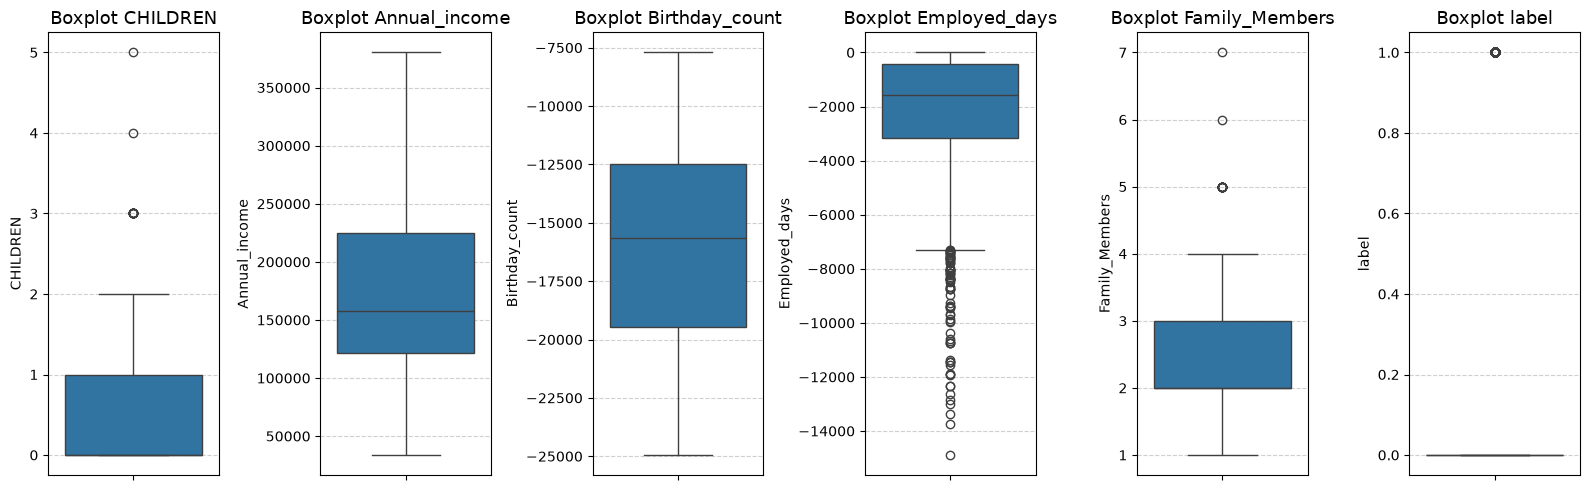

In [746]:
fig, axes = plt.subplots(ncols=len(num_cols), nrows=1, figsize=(16,5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data = df,
        y = col,
        ax = axes[i],
        legend = False,
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Siguemos teniendo outliers, en especial en la variable `Employed_days`. Sin embargo, considerando que existen adultos que llevan trabajando mucho tiempo podria estar en un punto razonable.

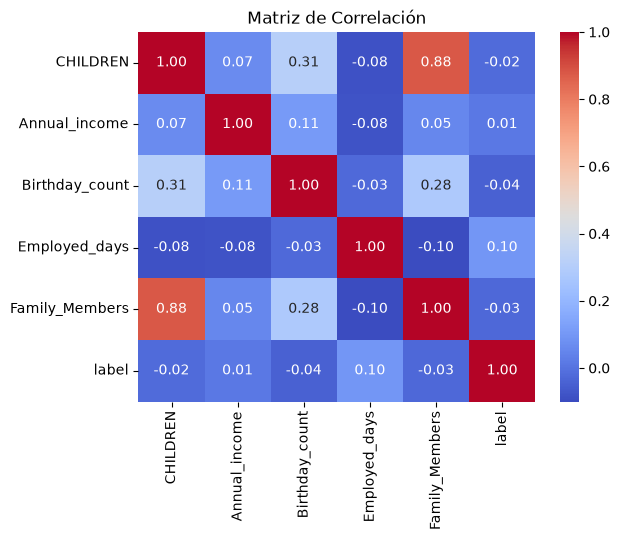

In [747]:
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [748]:
correlation_matrix

,CHILDREN,Annual_income,Birthday_count,Employed_days,Family_Members,label
CHILDREN,1.000000,0.065222,0.309444,-0.083669,0.879004,-0.020893
Annual_income,0.065222,1.000000,0.109319,-0.079135,0.051810,0.013003
Birthday_count,0.309444,0.109319,1.000000,-0.025489,0.282039,-0.044918
Employed_days,-0.083669,-0.079135,-0.025489,1.000000,-0.099886,0.097014
Family_Members,0.879004,0.051810,0.282039,-0.099886,1.000000,-0.030348
label,-0.020893,0.013003,-0.044918,0.097014,-0.030348,1.000000


vemos que tenemos variables que estan muy relacionadas con es el caso de `CHILDREN` y `Family_Members` , y esto podria afectar a nuestro modelo. Confirmaremos usando el VIF. Si el VIF > 5 podemos descartar variables. Vemos que `CHILDREN` y `Family_Members`; sin embargo, podemos quedarnos con una sola variable que agrupe a todo. En este caso, asumimos que `Family_Members` nos da mayor informacion.

In [749]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols_vif = [column for column in num_cols if column not in ['label']]
X_vif = df[num_cols_vif].dropna()

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,Variable,VIF
0,CHILDREN,4.483628
4,Family_Members,4.415620
2,Birthday_count,1.116435
1,Annual_income,1.019191
3,Employed_days,1.015925


In [750]:
df.drop('CHILDREN', axis = 1, inplace=True)

Continuamos con el análisis de las variables ahora categoricas

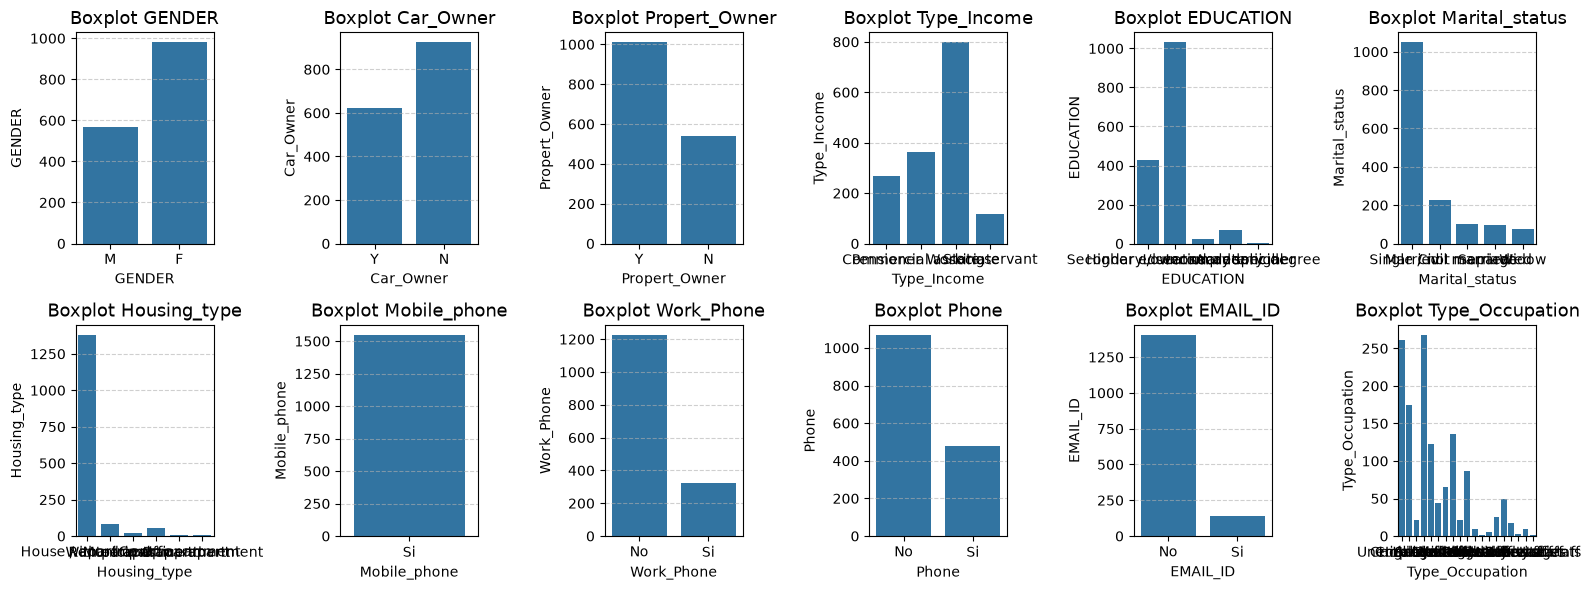

In [751]:
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Vemos que algunas variables tiene muchas categorias. Por lo tanto tenemos que agruparlas con sentido.

In [752]:
df['Marital_status'].value_counts()

Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

En el caso de la variable `Marital_status` podemos agrupar solo casados, por el resto de categorias no tendria mucho sentido. 

In [753]:
df['Marital_status'] = df['Marital_status'].replace('Civil marriage', 'Married')
df['Marital_status'].value_counts()

Marital_status
Married                 1150
Single / not married     227
Separated                 96
Widow                     75
Name: count, dtype: int64

Continuando con la variable `Housing_type` podemos agrupar algunos elementos en rent. 

In [754]:
# Definimos nuestro límite de obsercaciones
threshold = 60

# Calculamos cuántos clientes hay en cada categoría
frecuencia = df['Housing_type'].value_counts()

# Filtramos y nos quedamos solo con los NOMBRES de las categorías que no llegan a X
categorias_raras = frecuencia[frecuencia < threshold].index

df['Housing_type'] = df['Housing_type'].replace(categorias_raras, 'Rent')

df['Housing_type'].value_counts()


Housing_type
House / apartment    1380
Rent                   88
With parents           80
Name: count, dtype: int64

En el caso de `Type_Occupation` podemos agrupar en ocupaciones que esten muy relacionadas y tengan sentido y reemplazar a los nulos con con desconocido. 

In [755]:
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [756]:
# Creamos el diccionario de mapeo con nuestra lógica de negocio
mapeo_profesiones = {
    # White Collar (Oficina / Alta cualificación)
    'IT staff': 'White_Collar',
    'Managers': 'White_Collar',
    'Core staff': 'White_Collar',
    'Accountants': 'White_Collar',
    'Medicine staff': 'White_Collar',
    'High skill tech staff': 'White_Collar',
    'HR staff': 'White_Collar',
    
    # Blue Collar (Manual / Operativo)
    'Laborers': 'Blue_Collar',
    'Drivers': 'Blue_Collar',
    'Security staff': 'Blue_Collar',
    'Low-skill Laborers': 'Blue_Collar',
    
    # Ventas y Administración
    'Sales staff': 'Sales_Services',
    'Realty agents': 'Sales_Services',
    'Secretaries': 'Sales_Services',
    
    # Hostelería y Limpieza
    'Cooking staff': 'Hospitality_Support',
    'Waiters/barmen staff': 'Hospitality_Support',
    'Cleaning staff': 'Hospitality_Support',

    "Unemployed": "Unemployed"
}

# Aplicamos el mapeo. Lo que no esté en el diccionario (los nulos), lo rellenamos con 'Desconocido'
df['Type_Occupation'] = df['Type_Occupation'].map(mapeo_profesiones).fillna('Desconocido')

# Comprobamos la nueva distribución y su Tasa de Mora
df.groupby('Type_Occupation')['label'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Type_Occupation,,
Hospitality_Support,0.145833,48
Unemployed,0.134100,261
Blue_Collar,0.121134,388
White_Collar,0.113924,474
Desconocido,0.090164,244
Sales_Services,0.075188,133


Continuando con la variable `EDUCATION`, agruparemos en 3 categrias similares con el fin de no alterar mucho las frecuencias

In [757]:
df['EDUCATION'].value_counts()

EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64

In [758]:
df['EDUCATION'] = df['EDUCATION'].replace('Academic degree', 'Higher education')
df['EDUCATION'] = df['EDUCATION'].replace(['Lower secondary', 'Secondary / secondary special'], 'Secondary')
df.groupby('EDUCATION')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
EDUCATION,,
Secondary,0.109316,1052
Higher education,0.128505,428
Incomplete higher,0.073529,68


Comprobamos como han quedado las variables categóricas, ahora de paso desagregando por impago para empezar a ver qué variables puedes ser más interesantes para predecir impagos.

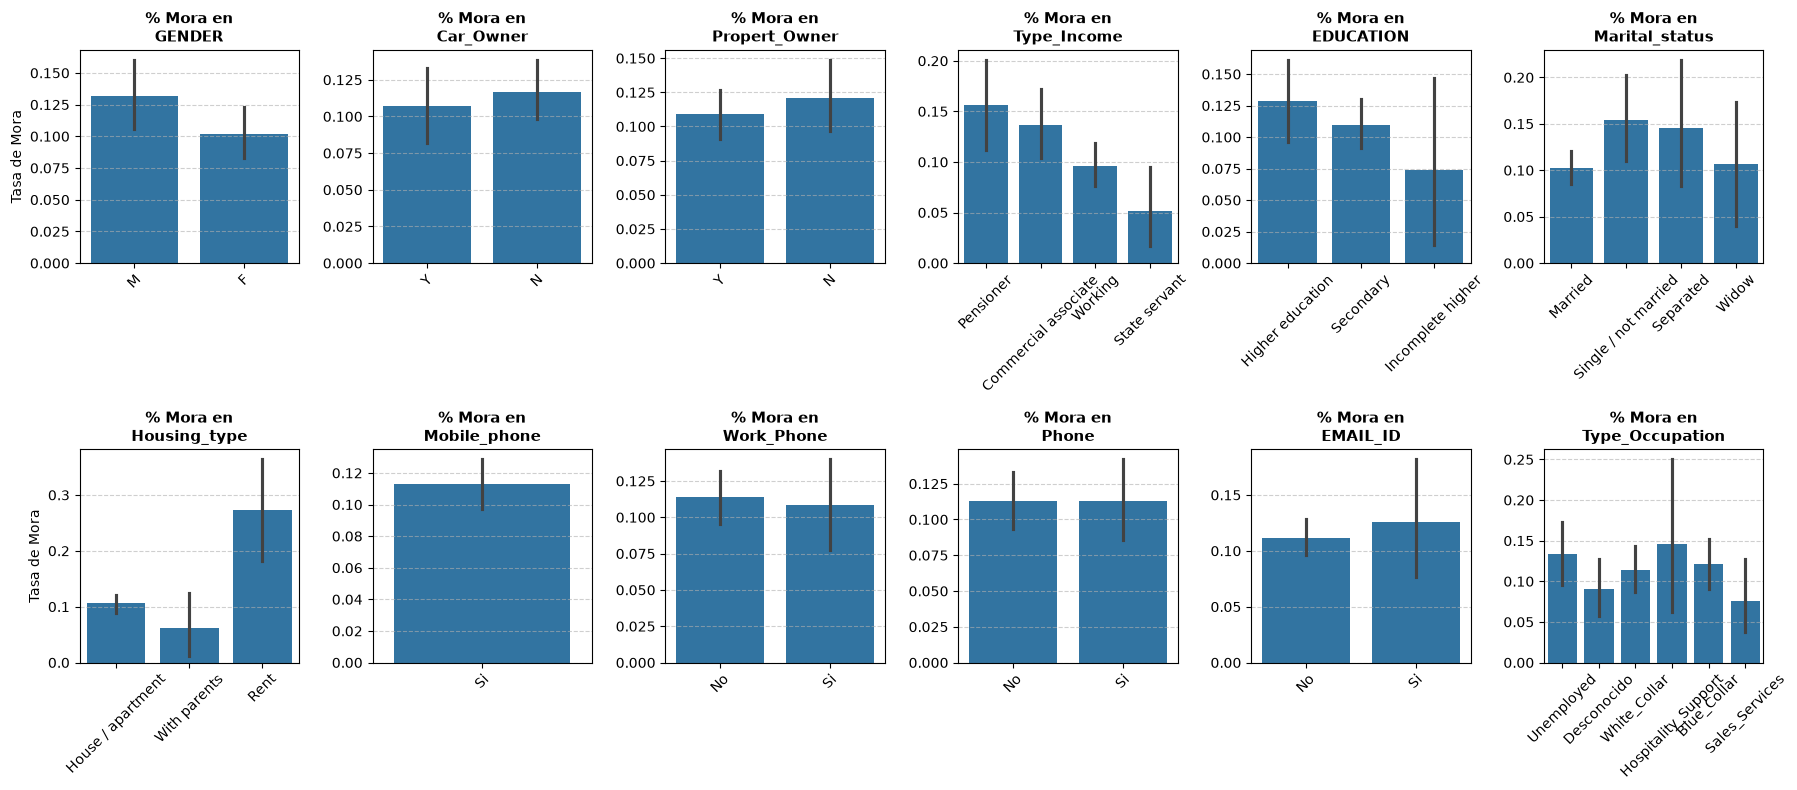

In [759]:
# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(18, 8)) # Un poco más grande para que quepan los textos
axes = axes.flatten()

# Iteración para pintar cada gráfico de barras con el % (Tasa de Mora)
for i, col in enumerate(cat_cols):
    # sns.barplot calcula la media por defecto (que en variables 0/1 es el %)
    sns.barplot(
        data=df, 
        x=col, 
        y='label',       # Al poner label en la Y, calcula la proporción de 1s
        ax=axes[i]
    )
    
    # Rotamos las etiquetas X porque en variables categóricas suelen solaparse
    axes[i].tick_params(axis='x', rotation=45) 
    
    # Títulos y etiquetas más precisos
    axes[i].set_title(f'% Mora en\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de Mora' if i % 6 == 0 else '') # Solo mostramos el nombre del eje Y en la primera columna
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Si tienes menos de 12 variables categóricas, esto borra los subplots vacíos que sobran
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Las variables categoricas queda mas limpias y legibles. Observamos algunos variables como `Mobile_phone` , `Work_Phone`, `Phone` , `EMAIL_ID` que podriamos eliminarlo, ya que es muy probable que no tenga capacidad predictiva. 

In [760]:
df.drop(['Mobile_phone','Work_Phone', 'Phone', 'EMAIL_ID'], axis = 1, inplace=True)

Vamos a ver ahora la relación de las variables numéricas y nuestra variable de interés.

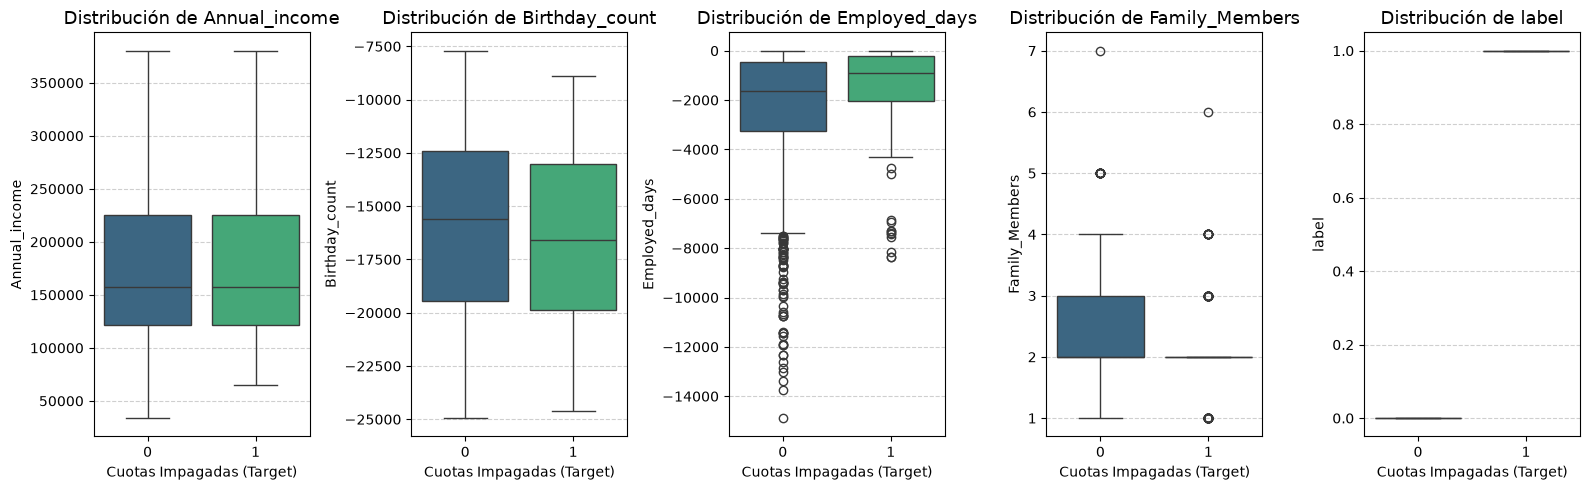

In [761]:
# Extraer de nuevo variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(16, 5))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='label', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='label',       # Añade color por categoría
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('Cuotas Impagadas (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Sorprendentemente el income no tiene mucha diferencia entre buenos y malos pagadores, pero si los miembros de la familia. 

# Modelado

comenzando definiendo nuestras variables predictoras e independientes`label` 

In [762]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Ahora construirmeos nuestras variables dummies y escalaremos las variables numéricas

In [763]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

# drop_first=True elimina la primera columna para evitar la trampa de multicolinealidad
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos las columnas del Train/Test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


In [764]:
# Escalamos variables numericas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(num_cols)

# Definicion del scaler
scaler = StandardScaler()

# Ajustamos (fit) SOLO con el train y transformamos ambos
# Esto evita que el modelo sepa de antemano el rango total de los datos de prueba
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

['Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members']


In [765]:
X_train.head()

,Annual_income,Birthday_count,Employed_days,Family_Members,GENDER_M,Car_Owner_Y,Propert_Owner_Y,Type_Income_Pensioner,Type_Income_State servant,Type_Income_Working,EDUCATION_Incomplete higher,EDUCATION_Secondary,Marital_status_Separated,Marital_status_Single / not married,Marital_status_Widow,Housing_type_Rent,Housing_type_With parents,Type_Occupation_Desconocido,Type_Occupation_Hospitality_Support,Type_Occupation_Sales_Services,Type_Occupation_Unemployed,Type_Occupation_White_Collar
1197,-0.604205,0.949059,0.125353,0.914565,True,True,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
416,-0.604205,0.787619,0.245722,2.011475,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
1234,-0.872929,-0.738546,0.918055,-0.182346,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False
31,-0.872929,-1.394559,0.918055,-0.182346,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False
583,0.739414,-1.449644,0.918055,-0.182346,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False


Entrenamos los modelos básicos con un bucle. Al final siempre se entrenan instanciando el modelo y llamando ``.fit()`` y ``.predict()``. Esto va a ser nuestro Benchmark para comparar los modelos "más complejos" que ajustemos después